In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import flopy

In [2]:
def transport_model(
    
    nrow=1,
    ncol=150,
    nlay=1,

    sim_ws="./simulation",
    species_list=["Species",],
    perlen=1826,
    nstp=200,
    initial_conc=np.ones(120000) * 0.05,
    bc=[0.1, 0.1, 0.1],
    porosity=0.25,
    K11=1.0,
    initial_head=1.0
):

    gwf_model_name = 'gwf_model'

    delr = [1.0] * ncol
    delc = [1.0]
    top  = 1.0
    botm = 0

    nper = 1
    tsmult = 1.0

    hk = K11
    
    sim = flopy.mf6.MFSimulation(
        sim_name="model",
        sim_ws=sim_ws,
        exe_name='mf6',
        verbosity_level=0
    )

    flopy.mf6.ModflowTdis(
        sim,
        pname='tdis',
        time_units='DAYS',
        nper=nper,
        perioddata=[(perlen, nstp, tsmult)]
    )

    gwf_model = flopy.mf6.ModflowGwf(
        sim, 
        modelname=gwf_model_name, 
        save_flows=False
    )
    
    ims = flopy.mf6.ModflowIms(
        sim,
        pname='ims',
        complexity='SIMPLE',
        outer_dvclose=1.0e-8,
        outer_maximum=50,
        under_relaxation='NONE',
        inner_maximum=100,
        inner_dvclose=1.0e-9,
        rcloserecord=1.0e-10,
        linear_acceleration='CG',
        scaling_method='NONE',
        reordering_method='NONE',
        relaxation_factor=0.97
    )
    sim.register_ims_package(ims, [gwf_model.name])

    flopy.mf6.ModflowGwfdis(
        gwf_model,
        pname='dis',
        nlay=nlay,
        nrow=nrow,
        ncol=ncol,
        delr=delr,
        delc=delc,
        top=top,
        botm=botm
    )

    flopy.mf6.ModflowGwfnpf(
        gwf_model,
        pname='npf',
        save_flows=True,
        save_specific_discharge=True,
        icelltype=0,
        k=hk,
        # k22=hk*0.1,
        # k33=hk*0.1
    )

    flopy.mf6.ModflowGwfic(
        gwf_model,
        pname='ic',
        strt=initial_head
    )

    flopy.mf6.ModflowGwfsto(
        gwf_model,
        pname='sto',
        save_flows=False,
        iconvert=1,
        ss=0.0,
        sy=0.0
    )

    chd_spd = [[(0, 0, 0), 4.725]]
    flopy.mf6.ModflowGwfchd(
        gwf_model,
        pname='chd',
        save_flows=True,
        maxbound=len(chd_spd),
        stress_period_data={0: chd_spd},
        filename=f"{gwf_model_name}.choushui.chd"
    )

    # chd2_spd = [[(0, 0, 0), 0.00695625, *bc],] # 0.007
    chd2_spd = [[(0, 0, ncol-1), 1.0],]
    flopy.mf6.ModflowGwfchd(
        gwf_model,
        pname='bushui',
        save_flows=True,
        maxbound=len(chd2_spd),
        stress_period_data={0: chd2_spd},
        # auxiliary=species_list,
        filename=f"{gwf_model_name}.bushui.chd"
    )

    flopy.mf6.ModflowGwfoc(
        gwf_model,
        pname='oc',
        budget_filerecord=f'{gwf_model_name}.bud',
        head_filerecord=f'{gwf_model_name}.hds',
        saverecord=[('HEAD', 'ALL'), ('BUDGET', 'LAST')],
        printrecord=[('HEAD', 'LAST'), ('BUDGET', 'LAST')]
    )

    sim.write_simulation(silent=False)
    sim.run_simulation()

    return sim, gwf_model

sim, gwf = transport_model()



In [3]:
head = sim.get_model("gwf_model").output.head().get_alldata()

head.shape

(200, 1, 1, 150)

In [4]:
head[-1, 0, 0]

array([4.725, 4.7  , 4.675, 4.65 , 4.625, 4.6  , 4.575, 4.55 , 4.525,
       4.5  , 4.475, 4.45 , 4.425, 4.4  , 4.375, 4.35 , 4.325, 4.3  ,
       4.275, 4.25 , 4.225, 4.2  , 4.175, 4.15 , 4.125, 4.1  , 4.075,
       4.05 , 4.025, 4.   , 3.975, 3.95 , 3.925, 3.9  , 3.875, 3.85 ,
       3.825, 3.8  , 3.775, 3.75 , 3.725, 3.7  , 3.675, 3.65 , 3.625,
       3.6  , 3.575, 3.55 , 3.525, 3.5  , 3.475, 3.45 , 3.425, 3.4  ,
       3.375, 3.35 , 3.325, 3.3  , 3.275, 3.25 , 3.225, 3.2  , 3.175,
       3.15 , 3.125, 3.1  , 3.075, 3.05 , 3.025, 3.   , 2.975, 2.95 ,
       2.925, 2.9  , 2.875, 2.85 , 2.825, 2.8  , 2.775, 2.75 , 2.725,
       2.7  , 2.675, 2.65 , 2.625, 2.6  , 2.575, 2.55 , 2.525, 2.5  ,
       2.475, 2.45 , 2.425, 2.4  , 2.375, 2.35 , 2.325, 2.3  , 2.275,
       2.25 , 2.225, 2.2  , 2.175, 2.15 , 2.125, 2.1  , 2.075, 2.05 ,
       2.025, 2.   , 1.975, 1.95 , 1.925, 1.9  , 1.875, 1.85 , 1.825,
       1.8  , 1.775, 1.75 , 1.725, 1.7  , 1.675, 1.65 , 1.625, 1.6  ,
       1.575, 1.55 ,

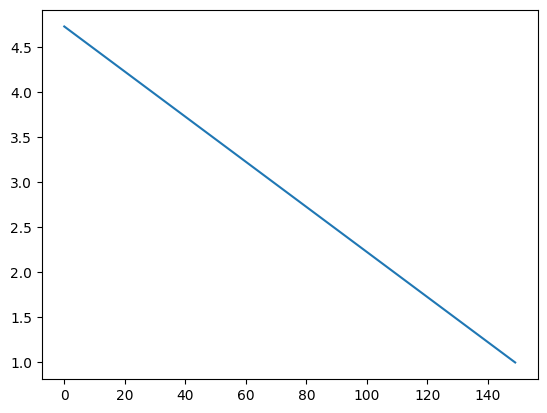

In [5]:
plt.plot(head[-1, 0, 0])

In [12]:
import flopy
import numpy as np
import matplotlib.pyplot as plt

sim = flopy.mf6.MFSimulation.load(
    sim_ws="./simulation/",
    sim_name="model",
    verbosity_level=0
)

gwf = sim.get_model("gwf_model")
bud = sim.get_model("gwf_model").output.budget()
# 读取所有SPDIS数据
spdis_all = bud.get_data(text='DATA-SPDIS')

# spdis_all = bud.get_data(text='FLOW-JA-FACE')
# spdis0 = bud.get_data(text='DATA-SPDIS')[0]
# spdis30 = bud.get_data(text='DATA-SPDIS')[-1]

# 初始化空列表
qx_list, qy_list, qz_list, speed_list = [], [], [], []

# 循环计算每个时刻的比流量和流速
for spdis in spdis_all:
    qx, qy, qz = flopy.utils.postprocessing.get_specific_discharge(spdis, gwf)
    speed = np.sqrt(qx**2 + qy**2 + qz**2)

    qx_list.append(qx)
    qy_list.append(qy)
    qz_list.append(qz)
    speed_list.append(speed)

# 堆叠为numpy数组，第0维是时间
qx_arr = np.stack(qx_list, axis=0)/ 0.25
qy_arr = np.stack(qy_list, axis=0)/ 0.25
qz_arr = np.stack(qz_list, axis=0)/ 0.25
speed_arr = np.stack(speed_list, axis=0)/ 0.25

print("qx_arr shape:", qx_arr.shape)   # (ntime, nlay, nrow, ncol)
print("speed_arr shape:", speed_arr.shape)


qx_arr shape: (1, 1, 1, 150)
speed_arr shape: (1, 1, 1, 150)


In [13]:
speed_arr

array([[[[0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1, 0.1,
          0.1, 0.1, 0.1, 0.1, 0.1, 0.1]]]])